In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

X,y = make_circles(noise=0.25,factor=0.5,random_state=1)

y_named = np.array(["blue","red"])[y]
X_train,X_test,y_train_named,y_test_named,y_train,y_test=train_test_split(
    X,y_named,y,random_state=0
)     #问一下split的用法和含义

print("数据集形状:",X.shape)
print("前5个标签:",y_train_named[:5])


数据集形状: (100, 2)
前5个标签: ['blue' 'blue' 'blue' 'blue' 'blue']


In [2]:
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train,y_train_named)

dec_func = gbrt.decision_function(X_test)
print("决策函数值形状:",dec_func.shape)
print("前6个决策函数值:",dec_func[:6])

pred_threshold = dec_func>0
print("阈值化后的预测:",pred_threshold[:6])
print("模型的predict输出:",gbrt.predict(X_test)[:6])

决策函数值形状: (25,)
前6个决策函数值: [ 4.13592603 -1.70169917 -3.95106099 -3.62609552  4.28986642  3.66166081]
阈值化后的预测: [ True False False False  True  True]
模型的predict输出: ['red' 'blue' 'blue' 'blue' 'red' 'red']


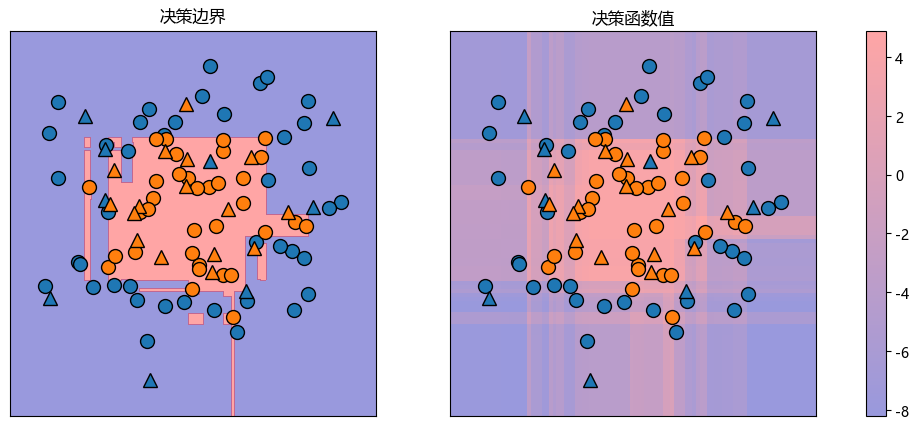

In [3]:
fig,axes = plt.subplots(1,2,figsize=(13,5))

mglearn.plots.plot_2d_separator(gbrt,X,ax=axes[0],alpha=0.4,fill=True,
                                cm=mglearn.cm2)
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train_named,ax=axes[0],markers='o')
mglearn.discrete_scatter(X_test[:,0],X_test[:,1],y_test_named,ax=axes[0],markers='^')
axes[0].set_title("决策边界")

scores_image = mglearn.tools.plot_2d_scores(gbrt,X,ax=axes[1],alpha=0.4,
                                            cm=mglearn.ReBl)
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train_named,ax=axes[1],markers='o')
mglearn.discrete_scatter(X_test[:,0],X_test[:,1],y_test_named,ax=axes[1],markers='^')
axes[1].set_title("决策函数值")
plt.colorbar(scores_image,ax=axes.tolist())
plt.show()

In [8]:
proba = gbrt.predict_proba(X_test)
print("预测概率形状:",proba.shape)
print("前6个预测概率:\n",proba[:6])

print("前6行概率和:",proba[:6].sum(axis=1))

pred_proba = np.argmax(proba,axis=1)
print("argmax结果:",pred_proba[:6])
print("类别映射:",gbrt.classes_)
print("预测的类别:",gbrt.classes_[pred_proba[:6]])

预测概率形状: (25, 2)
前6个预测概率:
 [[0.01573626 0.98426374]
 [0.84575653 0.15424347]
 [0.98112869 0.01887131]
 [0.97407033 0.02592967]
 [0.01352142 0.98647858]
 [0.02504637 0.97495363]]
前6行概率和: [1. 1. 1. 1. 1. 1.]
argmax结果: [1 0 0 0 1 1]
类别映射: ['blue' 'red']
预测的类别: ['red' 'blue' 'blue' 'blue' 'red' 'red']


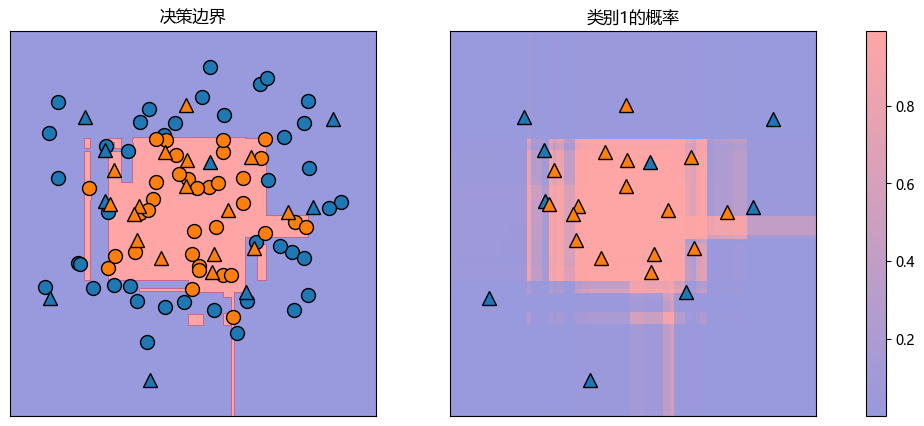

In [7]:
fig,axes = plt.subplots(1,2,figsize=(13,5))

mglearn.plots.plot_2d_separator(gbrt,X,ax=axes[0],alpha=0.4,fill=True,cm=mglearn.cm2)
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train_named,ax=axes[0],markers='o')
mglearn.discrete_scatter(X_test[:,0],X_test[:,1],y_test_named,ax=axes[0],markers='^')
axes[0].set_title("决策边界")

scores_image = mglearn.tools.plot_2d_scores(gbrt,X,ax=axes[1],alpha=0.4,cm=mglearn.ReBl,function='predict_proba')
mglearn.discrete_scatter(X_test[:,0],X_test[:,1],y_test_named,ax=axes[1],markers='^')
axes[1].set_title("类别1的概率")
plt.colorbar(scores_image,ax=axes.tolist())
plt.show()

In [10]:
from sklearn.datasets import load_iris
iris = load_iris()
X_train,X_test,y_train,y_test=train_test_split(iris.data,iris.target,random_state=42)

gbrt_iris = GradientBoostingClassifier(learning_rate=0.01,random_state=0)
gbrt_iris.fit(X_train,y_train)

dec_func_iris = gbrt_iris.decision_function(X_test)
print("决策函数形状:",dec_func_iris.shape)

proba_iris = gbrt_iris.predict_proba(X_test)
print("预测概率形状:",proba_iris[:3])
print("前3个样本的概率:\n",proba_iris[:3])

pred_classes = np.argmax(proba_iris, axis=1)
print("预测类别:",pred_classes[:10])
print("真实类别:",y_test[:10])

决策函数形状: (38, 3)
预测概率形状: [[0.10217718 0.78840034 0.10942248]
 [0.78347147 0.10936745 0.10716108]
 [0.09818072 0.11005864 0.79176065]]
前3个样本的概率:
 [[0.10217718 0.78840034 0.10942248]
 [0.78347147 0.10936745 0.10716108]
 [0.09818072 0.11005864 0.79176065]]
预测类别: [1 0 2 1 1 0 1 2 1 1]
真实类别: [1 0 2 1 1 0 1 2 1 1]
